vLLM is a high-performance library designed for LLM inference and serving that utilizes PagedAttention to manage memory more efficiently than traditional methods. It significantly increases throughput and reduces latency, making it ideal for serving models like DeepSeek-OCR in high-demand environments.

In [1]:
pip install vllm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.9/474.9 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 355.0/355.0 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.0/183.0 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 135.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 82.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 140.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.2/96.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0

In [1]:
from vllm import LLM

llm = LLM(model="facebook/opt-125m")
outputs = llm.generate("Hello, my name is")

for output in outputs:
    prompt = output.prompt
    generated_text = output.outputs[0].text
    print(f"Prompt: {prompt}, Generated text: {generated_text}")

INFO 12-19 16:43:58 [utils.py:253] non-default args: {'disable_log_stats': True, 'model': 'facebook/opt-125m'}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/651 [00:00<?, ?B/s]

INFO 12-19 16:44:17 [model.py:514] Resolved architecture: OPTForCausalLM
INFO 12-19 16:44:17 [model.py:1661] Using max model len 2048
INFO 12-19 16:44:19 [scheduler.py:230] Chunked prefill is enabled with max_num_batched_tokens=8192.


tokenizer_config.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

WARNING 12-19 16:44:21 [system_utils.py:136] We must use the `spawn` multiprocessing start method. Overriding VLLM_WORKER_MULTIPROC_METHOD to 'spawn'. See https://docs.vllm.ai/en/latest/usage/troubleshooting.html#python-multiprocessing for more information. Reasons: CUDA is initialized
INFO 12-19 16:47:53 [llm.py:360] Supported tasks: ['generate']


Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Prompt: Hello, my name is, Generated text: ' Joel, my dad is Anton Harriman and my wife is Lydia. '


LanceDB is an open-source database for vector search. It is "serverless" (runs locally) and supports metadata filtering, which is a requirement for your project.

In [3]:
pip install lancedb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.9/45.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.8/256.8 kB 25.5 MB/s eta 0:00:00


In [4]:
# Installation: pip install lancedb
import lancedb
import pandas as pd

# Connect to a local database
db = lancedb.connect("./lancedb_data")

# Define a schema/data (including metadata for filtering)
data = [
    {"vector": [0.1, 0.2], "text": "قانون مالیات", "law_type": "tax", "year": 1402},
    {"vector": [0.3, 0.4], "text": "حقوق مدنی", "law_type": "civil", "year": 1401}
]

# Create a table
table = db.create_table("legal_docs", data=data, mode="overwrite")

# Search with metadata filtering
result = table.search([0.1, 0.2]).where("law_type = 'tax'").limit(1).to_pandas()
print(result)

       vector          text law_type  year  _distance
0  [0.1, 0.2]  قانون مالیات      tax  1402        0.0


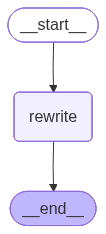

In [7]:
# Installation: pip install langgraph
from typing import TypedDict, List
from langgraph.graph import StateGraph, END
from IPython.display import Image, display

# Define the state of our agent
class AgentState(TypedDict):
    query: str
    rewritten_query: str
    context: List[str]
    answer: str

# Define a simple node
def rewrite_query_node(state: AgentState):
    # Logic to rewrite query
    return {"rewritten_query": f"Rewritten: {state['query']}"}

# Construct the graph
workflow = StateGraph(AgentState)
workflow.add_node("rewrite", rewrite_query_node)
workflow.set_entry_point("rewrite")
workflow.add_edge("rewrite", END)

app = workflow.compile()
display(Image(app.get_graph().draw_mermaid_png()))

In [8]:
inputs = {
    "query": "قانون مالیات بر خانه‌های خالی چیست؟",
    "rewritten_query": "",
    "context": [],
    "answer": ""
}


final_state = app.invoke(inputs)


print(f"Original Query: {final_state['query']}")
print(f"Result (Rewritten): {final_state['rewritten_query']}")

Original Query: قانون مالیات بر خانه‌های خالی چیست؟
Result (Rewritten): Rewritten: قانون مالیات بر خانه‌های خالی چیست؟


RAGAS is a framework that helps you evaluate your RAG pipelines using metrics like faithfulness and relevancy without needing human-labeled ground truth for every step.

In [10]:
pip install ragas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.9/419.9 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.9/160.9 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 57.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.7/84.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 476.4/476.4 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.8/358.8 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.4/226.4 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50

In [39]:
from openai import AsyncOpenAI
from ragas.llms import llm_factory
from ragas.embeddings.base import embedding_factory
from ragas.metrics.collections import AnswerRelevancy
from dotenv import load_dotenv

load_dotenv()
# Setup LLM and embeddings
client = AsyncOpenAI(api_key=os.getenv("OPENAI_API_KEY"))
llm = llm_factory("gpt-4o-mini", client=client)
embeddings = embedding_factory("openai", model="text-embedding-3-small", client=client)

# Create metric
scorer = AnswerRelevancy(llm=llm, embeddings=embeddings)

# Evaluate
result = await scorer.ascore(
    user_input="When was the first super bowl?",
    response="The first superbowl was held on Jan 15, 1967"
)
print(f"Answer Relevancy Score: {result.value}")

Answer Relevancy Score: 0.9165168039895201
